# Emotion Classification 
- with RNNs, LSTMs and GRUs

### classifying text into 6 emotions (sadness ,joy love, anger, fear, surprise)

### Import Libraries


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#this library help to import dataset from  hugging face

from datasets import load_dataset

### 2 Load data set

In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')

In [4]:
train_text=emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [6]:
label_names = emotion_dataset['train'].features['label'].names

print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [7]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

In [8]:
print(df_train.head())

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [9]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

# EDA (Exploratory Data Analysis)

<Axes: xlabel='label', ylabel='count'>

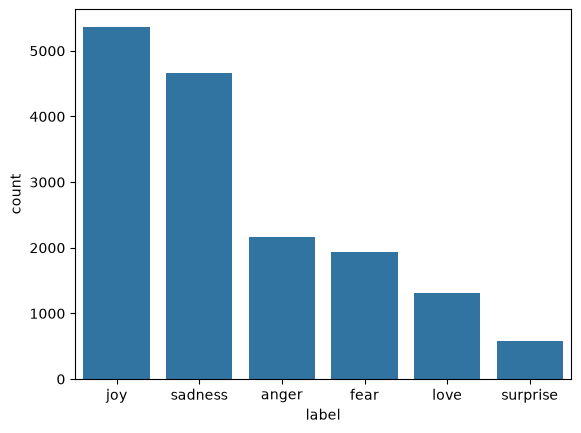

In [10]:
sns.countplot(x = 'label', data= df_train, order= df_train['label'].value_counts().index)

# Data Preprocessing - Using NLP
- tokenize text, pad sequences to max length 50, and convert labels into numpy array

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train['text']) #what it does it ..... "I love u" in this text each works is given rank

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen= 50, padding='post', truncating= 'post') #this is train X
padded_test_sequence = pad_sequences(test_sequence, maxlen= 50, padding='post', truncating= 'post')   # this is test X

train_labels = np.array(train_label) # this is train Y
test_labels = np.array(test_label)   # this is test Y
num_classes = len(np.unique(train_labels))

In [12]:
print(f"Vocabulary Size:{len(tokenizer.word_index)}")
print(f"Max Sentences Length: {padded_train_sequence.shape[1]}")

Vocabulary Size:15213
Max Sentences Length: 50


# Shared Training Utilities
- compute class weight mannually


In [13]:
from sklearn.utils import class_weight

In [14]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes= np.unique(train_labels),
    y= train_labels
)


In [15]:
class_weight_dict = dict(enumerate(class_weights))

- now apply early stoping

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### RNN

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50), #input length means how many words in a sentence
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.50),
    SimpleRNN(units=64),
    Dropout(0.50), # to prevent obverfitting we drop 50 percent of the layers
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\Nitro5\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.1561 - loss: 2.0784 - val_accuracy: 0.0530 - val_loss: 1.8564
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1473 - loss: 1.8842 - val_accuracy: 0.1375 - val_loss: 1.7766
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1378 - loss: 1.8301 - val_accuracy: 0.1375 - val_loss: 1.7773
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.1336 - loss: 1.8082 - val_accuracy: 0.1375 - val_loss: 1.7806
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1424 - loss: 1.8016 - val_accuracy: 0.1120 - val_loss: 1.7886


In [19]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"Simple RNN test loss: {rnn_loss}")
print(f"RNN accuracy: {rnn_accuracy}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1375 - loss: 1.7766
Simple RNN test loss: 1.7766035795211792
RNN accuracy: 0.13750000298023224


### LSTM

In [20]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50), #input length means how many words in a sentence
    LSTM(units=128, return_sequences=True),
    Dropout(0.50),
    LSTM(units=64),
    Dropout(0.50), # to prevent obverfitting we drop 50 percent of the layers
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.1407 - loss: 1.7950 - val_accuracy: 0.1140 - val_loss: 1.7927
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1472 - loss: 1.7939 - val_accuracy: 0.3385 - val_loss: 1.7886
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1349 - loss: 1.7922 - val_accuracy: 0.1345 - val_loss: 1.7934
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1527 - loss: 1.7761 - val_accuracy: 0.1740 - val_loss: 1.7179
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.3582 - loss: 1.4095 - val_accuracy: 0.4365 - val_loss: 1.0788
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.6935 - loss: 0.8117 - val_accuracy: 0.8480 - val_loss: 0.5122
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8716 - loss: 0.4371 - val_accuracy: 0.8850 - val_loss: 0.4170
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9077 - loss: 0.3250 - 

In [22]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM test loss: {lstm_loss}")
print(f"LSTM accuracy: {lstm_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9225 - loss: 0.2427
LSTM test loss: 0.24272727966308594
LSTM accuracy: 0.9225000143051147


### GRU

In [23]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50), #input length means how many words in a sentence
    LSTM(units=128, return_sequences=True),
    Dropout(0.50),
    LSTM(units=64),
    Dropout(0.50), # to prevent obverfitting we drop 50 percent of the layers
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [24]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.1516 - loss: 1.7945 - val_accuracy: 0.3400 - val_loss: 1.7935
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1536 - loss: 1.7938 - val_accuracy: 0.0360 - val_loss: 1.8023
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1733 - loss: 1.7902 - val_accuracy: 0.0345 - val_loss: 1.7994
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1693 - loss: 1.7639 - val_accuracy: 0.1905 - val_loss: 1.7751
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.2525 - loss: 1.5956 - val_accuracy: 0.2780 - val_loss: 1.4938
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.3461 - loss: 1.2871 - val_accuracy: 0.2675 - val_loss: 1.2908
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.5346 - loss: 0.8907 - val_accuracy: 0.6020 - val_loss: 0.9217
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.6648 - loss: 0.6239 - 

In [25]:
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU test loss: {gru_loss}")
print(f"GRU accuracy: {gru_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9100 - loss: 0.2922
GRU test loss: 0.2921987473964691
GRU accuracy: 0.9100000262260437


### Phase  Ranking and selection

In [26]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test_loss': [rnn_loss, lstm_loss, gru_loss],
    'Test_Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]  
}).sort_values(by='Test_Accuracy', ascending= False)

In [27]:
result_df

,Model,Test_loss,Test_Accuracy
1,LSTM,0.242727,0.9225
2,GRU,0.292199,0.9100
0,RNN,1.776604,0.1375


# Phase 2 - Advanced Bidirection GRU

In [28]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

c:\Users\Nitro5\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.5981 - loss: 1.0098 - val_accuracy: 0.8960 - val_loss: 0.3288
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.9202 - loss: 0.2273 - val_accuracy: 0.9175 - val_loss: 0.2297
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9460 - loss: 0.1466 - val_accuracy: 0.9100 - val_loss: 0.2760
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9629 - loss: 0.1036 - val_accuracy: 0.9175 - val_loss: 0.2844
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9697 - loss: 0.0834 - val_accuracy: 0.9185 - val_loss: 0.2767


In [30]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss:{BiGRU_loss}")
print(f"BiGRU Loss:{BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9175 - loss: 0.2297
BiGRU Loss:0.2296883910894394
BiGRU Loss:0.9175000190734863


# Overall Evaluation Bias

- Final model Confusion Matrix

In [31]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1) #It helps to choose the output which has the max output


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


<Axes: >

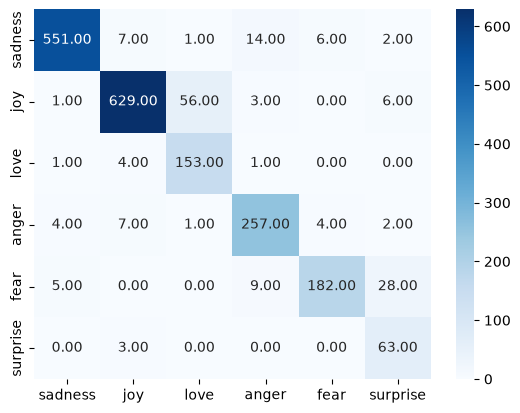

In [32]:

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, cmap='Blues', fmt='.2f', xticklabels=label_names, yticklabels=label_names)

# Final Predictions

In [33]:
sample_texts = [
    "I am feeling incredibly happy today, everything is going perfectly!",
    "I feel sad and completely empty after hearing the terrible news.",
    "I am extremely angry that they blamed me for something I didn't do.",
    "I feel scared and nervous whenever I have to walk home alone at night.",
    "I was completely surprised when my friends organized a birthday party for me.",
    "I am so excited about the trip we are going on next week!",
    "I feel calm and peaceful while sitting quietly near the lake."
]

sample_sequence = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequence, maxlen=50, padding= 'post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [34]:
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}\nPredicted emotion:{label_names[sample_predictions[i]]}")

Text: I am feeling incredibly happy today, everything is going perfectly!
Predicted emotion:joy
Text: I feel sad and completely empty after hearing the terrible news.
Predicted emotion:sadness
Text: I am extremely angry that they blamed me for something I didn't do.
Predicted emotion:anger
Text: I feel scared and nervous whenever I have to walk home alone at night.
Predicted emotion:fear
Text: I was completely surprised when my friends organized a birthday party for me.
Predicted emotion:surprise
Text: I am so excited about the trip we are going on next week!
Predicted emotion:joy
Text: I feel calm and peaceful while sitting quietly near the lake.
Predicted emotion:joy


# Save Model and Tokenizer

In [35]:
import joblib
import os 
import pickle

In [36]:
# we will export BiGRU and tokenizer
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) 

In [37]:
# save our BiGRU model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

In [38]:
# Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)